# Notebook 5: Response Heterogeneity

This notebook addresses the project's main question: how consistently do cells respond to the same genetic perturbation?

For each perturbation, response is separated into two components:

* **Magnitude:** how far the perturbation group's centroid is from the control centroid, representing the systematic expression change.
* **Heterogeneity:** how much individual cells vary around their own perturbation-group centroid, representing response variability within the group.

Together, these distinguish a consistent response from a response that varies substantially across cells.

The relationship

`mean squared distance from control = magnitude² + heterogeneity²`

is verified directly as a mathematical consistency check.


## Setup

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Loading the data

In [2]:
data_path = "F:/scRNA/adamson_pilot_with_response.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5752 × 14690
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'response_magnitude'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mean_log_expression', 'variance_log_expression', 'dispersion', 'highly_variable'
    obsm: 'X_pca'
    layers: 'counts'

In [3]:
control_label = "62(mod)_pBA581"
is_control = (adata.obs["perturbation"] == control_label).values

hvg_mask = adata.var["highly_variable"]
X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)

control_centroid = X_hvg[is_control].mean(axis=0)

## Computing magnitude and heterogeneity for every group


In [4]:
categories = adata.obs["perturbation"].cat.categories

rows = []
for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    group_X = X_hvg[mask]
    group_centroid = group_X.mean(axis=0)

    magnitude = np.linalg.norm(group_centroid - control_centroid)
    sq_dev_from_own_centroid = np.sum((group_X - group_centroid) ** 2, axis=1)
    heterogeneity = np.sqrt(sq_dev_from_own_centroid.mean())

    rows.append({
        "perturbation": cat,
        "n_cells": mask.sum(),
        "magnitude": magnitude,
        "heterogeneity": heterogeneity,
    })

response_summary = pd.DataFrame(rows).set_index("perturbation")
response_summary.sort_values("magnitude", ascending=False)

,n_cells,magnitude,heterogeneity
perturbation,,,
SPI1_pDS255,696,0.906861,6.401363
BHLHE40_pDS258,553,0.700858,6.078880
SNAI1_pDS266,562,0.509289,6.193193
DDIT3_pDS263,477,0.378645,5.949718
ZNF326_pDS262,557,0.373506,5.857707
EP300_pDS268,632,0.342509,5.920628
CREB1_pDS269,506,0.331550,5.997235
62(mod)_pBA581,1769,0.000000,6.063178


## Checking the identity holds



In [5]:
sq_dev_from_control = adata.obs["response_magnitude"].values ** 2

check_rows = []
for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    lhs = sq_dev_from_control[mask].mean()
    rhs = response_summary.loc[cat, "magnitude"] ** 2 + response_summary.loc[cat, "heterogeneity"] ** 2
    check_rows.append({"perturbation": cat, "mean_sq_dist_from_control": lhs,
                        "magnitude_sq_plus_heterogeneity_sq": rhs,
                        "difference": lhs - rhs})

identity_check = pd.DataFrame(check_rows).set_index("perturbation")
print("max absolute difference:", identity_check["difference"].abs().max())
identity_check

max absolute difference: 4.4880632685817545e-06


,mean_sq_dist_from_control,magnitude_sq_plus_heterogeneity_sq,difference
perturbation,,,
62(mod)_pBA581,36.762127,36.762122,4.488063e-06
BHLHE40_pDS258,37.443985,37.443988,-2.603445e-06
CREB1_pDS269,36.076752,36.076751,5.461399e-07
DDIT3_pDS263,35.542519,35.542516,2.315815e-06
EP300_pDS268,35.171143,35.171143,-8.630834e-07
SNAI1_pDS266,38.615021,38.615020,3.259350e-07
SPI1_pDS255,41.799843,41.799844,-7.615641e-07
ZNF326_pDS262,34.452236,34.452238,-2.026915e-06


## Magnitude vs. heterogeneity, by perturbation

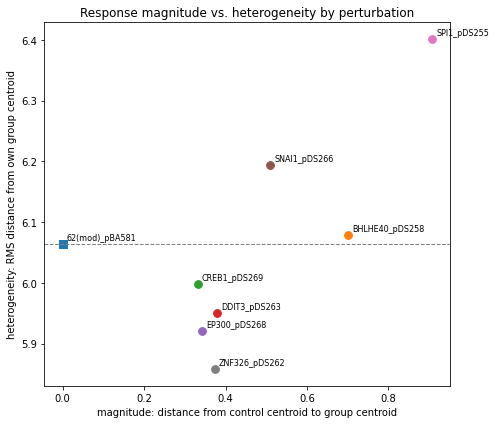

In [6]:
control_heterogeneity = response_summary.loc[control_label, "heterogeneity"]

fig, ax = plt.subplots(figsize=(7, 6))
for cat in categories:
    row = response_summary.loc[cat]
    marker = "s" if cat == control_label else "o"
    ax.scatter(row["magnitude"], row["heterogeneity"], s=60, marker=marker)
    ax.annotate(str(cat), (row["magnitude"], row["heterogeneity"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axhline(control_heterogeneity, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("magnitude: distance from control centroid to group centroid")
ax.set_ylabel("heterogeneity: RMS distance from own group centroid")
ax.set_title("Response magnitude vs. heterogeneity by perturbation")
plt.tight_layout()
plt.show()

## Heterogeneity relative to control's own baseline

In [7]:
response_summary["heterogeneity_ratio_to_control"] = (
    response_summary["heterogeneity"] / control_heterogeneity
)
response_summary.sort_values("heterogeneity_ratio_to_control", ascending=False)

,n_cells,magnitude,heterogeneity,heterogeneity_ratio_to_control
perturbation,,,,
SPI1_pDS255,696,0.906861,6.401363,1.055777
SNAI1_pDS266,562,0.509289,6.193193,1.021443
BHLHE40_pDS258,553,0.700858,6.078880,1.002590
62(mod)_pBA581,1769,0.000000,6.063178,1.000000
CREB1_pDS269,506,0.331550,5.997235,0.989124
DDIT3_pDS263,477,0.378645,5.949718,0.981287
EP300_pDS268,632,0.342509,5.920628,0.976489
ZNF326_pDS262,557,0.373506,5.857707,0.966112


## Saving


In [8]:
response_summary.to_csv("F:/scRNA/response_heterogeneity_summary.csv")
print("saved to data/response_heterogeneity_summary.csv")

saved to data/response_heterogeneity_summary.csv
